### Модели классификации

#### Цель работы

Познакомиться с основными приемами работы с моделями классификации в scikit-learn.

#### Задания для выполнения

1. Загрузите [данные](https://www.kaggle.com/uciml/pima-indians-diabetes-database) о диагностике сахарного диабета.
3. Постройте модель классификации для предсказания наличия заболевания.
4. Оцените качество построенной модели с помощью отчета о классификации и матрицы классификации.
5. Постройте альтернативную полиномиальную модель, сравните ее с предыдущей.

#### Методические указания

Для начала работы обратимся к набору данных diabetes. Это довольно известный датасет, собравший информацию о медицинских показателях более 700 пациентов, обследованных на предмет наличия сахарного диабета. На нем мы потренируемся строить классификационные модели. 

Сперва загрузим исходный набор данных. Это можно сделать, как скопировав файл csv в локальную папку, так и по общедоступному URL:

In [57]:
import pandas as pd
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML2.2%20real%20classification/data/diabetes.csv")

Обратите внимание, что в библиотеке _sklearn_ встроен очень похожий датасет pima-indian-diabetes. Имейте в виду, что в данной работе используется немного другой датасет.

Как и ранее, хорошей идеей перед началом анализа будет познакомиться с составом набора данных визуально. Выведем датасет на экран:

In [58]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Познакомьтесь с основной структурой датасета.

При проведении серьезного анализа перед построением модели машинного обучения нужно провести тщательную обработку и очистку набора данных - удаление пропущенных значений, анализ шкал, нормализация, удаление выбросов и аномалий. В учебных целях ограничимся обязательными проверками критических ошибок в данных.

В первую очередь проверим данные на наличие пропущенных значений:

In [59]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Видим, что пропусков в данных нет. Кроме того, видно, что все данные выражены в численных шкалах. Значит, особенной обработки данный датасет не требует, он уже достаточно чистый. Теперь можно вывести основную статистику по датасету:

In [60]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Здесь мы видим шкалу измерения каждого признака. Можно придти к выводу, что явных видимых аномалий в данных нет. отдельно обратим внимание на столбец "Outcome" - он содержит целевую переменную.  В данном случае она также выражается числом (0 - здоров, 1 - болен), но это не всегда так.

Теперь выделим целевую переменную и факторы:

In [61]:
y = data.Outcome
X = data.drop(["Outcome"], axis=1)

Выведем форму получившихся массивов:

In [62]:
y.shape, X.shape

((768,), (768, 8))

Данные выглядят полностью готовыми к началу машинного обучения. Для начала импортируем нужный класс и создадим его экземпляр:

In [63]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()

Обучим созданную модель на имеющихся у нас данных:

In [64]:
logistic.fit(X, y)

/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

После выполнения этой инструкции мы можем увидеть специальное предупреждение.

Смысл этого сообщения в том, что процесс обучения завершился по условию достижения максимального количества итераций, а не по условию стабилизации функции ошибки. Это значит, что модель обучается трудно и медленно. Это может свидетельствовать о том, что результаты могут быть не очень удовлетворительными.

Но давайте посмотрим, что за модель мы получили после такого обучения. В первую очередь выведем коэффициенты модели:

In [65]:
print("Coefficients: \n", logistic.coef_[0])

Coefficients: 
 [ 1.17252348e-01  3.36001424e-02 -1.40872986e-02 -1.27037878e-03
 -1.24033826e-03  7.72020114e-02  1.41904264e+00  1.00350891e-02]


В линейных моделях коэффициенты имеют физический смысл - они показывают значимость соответствующих признаков. Поэтому представляет особый интерес посмотреть коэффициенты вместе с названиями признаков.

Для этого соединим массив названий колонок из датасета и массив коэффициентов. Можно использовать, например, генераторное выражение для прохода по получившемуся массиву. Конструкция "\_ = [ ... ]" нужна только в ноутбуке для того, чтобы подавить автоматический вывод выражения:

In [66]:
_ = [print(k, v) for k, v in zip(X.columns, logistic.coef_[0])]

Pregnancies 0.11725234808012788
Glucose 0.033600142398877694
BloodPressure -0.014087298647387265
SkinThickness -0.0012703787783052332
Insulin -0.0012403382628561567
BMI 0.07720201139735491
DiabetesPedigreeFunction 1.419042642437566
Age 0.0100350890899355


Самостоятельно проанализируйте эти данные и сделайте вывод, какие атрибуты оказывают большее влияние на значение целевой переменной.

Чем больше абсолютное значение коэффициента, тем сильнее признак влияет на предсказание (при прочих равных). Положительный коэффициент увеличивает вероятность класса 1 (диабет), отрицательный — снижает.

Наибольшее влияние (положительное):

DiabetesPedigreeFunction (1.419) — наследственная предрасположенность, самый сильный фактор риска.

Pregnancies (0.117) — количество беременностей, также значимый фактор.

BMI (0.077) — индекс массы тела, ожирение повышает риск.

Glucose (0.034) — уровень глюкозы, логично, что это важный предиктор.

Слабое положительное влияние:

Age (0.010) — возраст, но влияние небольшое.

Отрицательное влияние (снижают риск):

BloodPressure (-0.014) — артериальное давление, чем выше, тем немного ниже риск (возможно, из-за особенностей данных или сопутствующих факторов).

SkinThickness (-0.0013) и Insulin (-0.0012) — влияние практически нулевое, эти признаки почти не влияют на модель.

Вывод: Наибольшее влияние на предсказание диабета оказывают DiabetesPedigreeFunction, Pregnancies, BMI и Glucose. Признаки толщины кожи и инсулина почти неинформативны в данной модели.

Как и в модели линейной регрессии, данный вектор не включает в себя свободный коэффициент. Он хранится в отдельном поле класса:

In [67]:
print("Intercept: \n", logistic.intercept_)

Intercept: 
 [-7.702939]


Теперь можно построить по полученной модели прогноз. Для этого передадим в соответствующий метод нашу матрицу признаков:

In [68]:
y_pred = logistic.predict(X)

Сформировав вектор предсказанных значений целевой переменной можно сравнить его с реальными значениями:

In [69]:
_ = [print(a, b) for a, b in list(zip(y, y_pred))[:10]]

1 1
0 0
1 1
0 0
1 1
0 0
1 0
0 1
1 1
1 0


Можно видеть, что большинство значений совпадает, но есть и ошибки - различия в значениях. Но так сравнивать все значения в ручном режиме очень неудобно. Поэтому лучше использовать специальные функции - метрики. Самая простая из них подсчитывает количество правильно и неправильно распознанных объектов и представляет результат в виде матрицы классификации:

In [70]:
from sklearn import metrics
metrics.confusion_matrix(y, y_pred)

array([[447,  53],
       [114, 154]])

Матрица классификации показывает нам очень полезную информацию: совместное распределение числа объектов предсказанных и реальных классов. Рассматривая эту матрицу мы можем получить важную информацию: сколько объектов мы классифицировали правильно, сколько неверно, к каким классам наша модель тяготеет, какие классы распознаются хорошо, какие - плохо

Гораздо удобнее анализировать ту же информацию в графической форме. Для этого воспользуемся специальной библиотекой _seaborn_, которая позволяет создавать полезные для машинного обучения визуализации очень просто:

<Axes: >

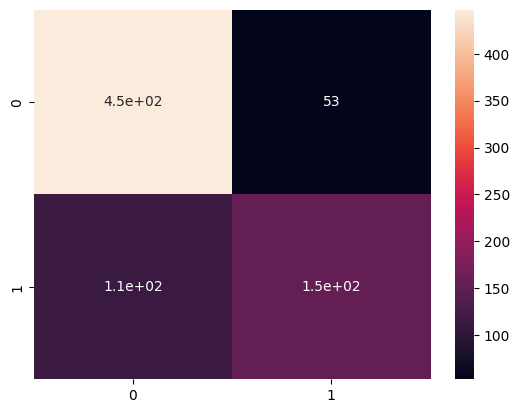

In [71]:
import seaborn as sns
sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True)

Кроме матрицы классификации весьма полезно использовать численные метрики эффективности классификации. Самая простая и распространенная из них - метрика точности предсказания - показывает долю правильно распознанных объектов. Расчет этой метрики встроен в сам объект модели и доступен с помощью специального метода:

In [72]:
logistic.score(X, y)

0.7825520833333334

Эту же метрику можно рассчитать и по-другому - через отдельную функцию из пакета _metrics_. Обратите внимание на другую сигнатуру метода:

In [73]:
metrics.accuracy_score(y, y_pred)

0.7825520833333334

Значение метрики (0,78) показывает, что модель в среднем делает ошибки в 22% процентов случаев. Это основной показатель качества модели. В дальнейших работах мы покажем, как его замерять более правильно.

Если же такой уровень эффективности нас не устраивает, то мы можем попробовать использовать другие классы моделей классификации и среди них выбрать наиболее качественную. Например, можно попробовать построить полиномиальную модель. В библиотеке _sklearn_ не предусмотрено отдельного класса полиномиальной модели. Ее можно создать через специальный объект _PolynomialFeature_, который добавляет полиномиальные признаки к данным. Для его использования сначала импортируем его:

In [74]:
from sklearn.preprocessing import PolynomialFeatures

Теперь можно создать объект преобразования (точно также как мы создавали объект модели):

In [75]:
poly = PolynomialFeatures(2)


Здесь мы указываем, что будем создавать полиномиальные признаки второго порядка. Теперь можно использовать этот объект для создания собственно самих признаков:

In [76]:
poly = poly.fit_transform(X)
poly

array([[1.00000e+00, 6.00000e+00, 1.48000e+02, ..., 3.93129e-01,
        3.13500e+01, 2.50000e+03],
       [1.00000e+00, 1.00000e+00, 8.50000e+01, ..., 1.23201e-01,
        1.08810e+01, 9.61000e+02],
       [1.00000e+00, 8.00000e+00, 1.83000e+02, ..., 4.51584e-01,
        2.15040e+01, 1.02400e+03],
       ...,
       [1.00000e+00, 5.00000e+00, 1.21000e+02, ..., 6.00250e-02,
        7.35000e+00, 9.00000e+02],
       [1.00000e+00, 1.00000e+00, 1.26000e+02, ..., 1.21801e-01,
        1.64030e+01, 2.20900e+03],
       [1.00000e+00, 1.00000e+00, 9.30000e+01, ..., 9.92250e-02,
        7.24500e+00, 5.29000e+02]], shape=(768, 45))

Теперь эти данные можно использовать как исходные для моделирования. А строить мы будем обычную логистическую регрессию:

In [77]:
polynomial = LogisticRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Исследуйте точность этой модели и сравните ее с линейной самостоятельно

Отчет о классификации

In [78]:
from sklearn.metrics import classification_report
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       500
           1       0.74      0.57      0.65       268

    accuracy                           0.78       768
   macro avg       0.77      0.73      0.75       768
weighted avg       0.78      0.78      0.77       768



Оценка полиномиальной модели

In [79]:
from sklearn.metrics import accuracy_score, confusion_matrix

print(f"Accuracy: {accuracy_score(y, y_pred_poly):.4f}")
print("Confusion matrix:\n", confusion_matrix(y, y_pred_poly))
print(classification_report(y, y_pred_poly))

Accuracy: 0.7240
Confusion matrix:
 [[405  95]
 [117 151]]
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       500
           1       0.61      0.56      0.59       268

    accuracy                           0.72       768
   macro avg       0.69      0.69      0.69       768
weighted avg       0.72      0.72      0.72       768



Точность линейной модели: 78.26%

Точность полиномиальной модели (степень 2): 72.40%

Возможная причина: - Линейная модель (8 признаков) показала accuracy = 78.26%.
Полиномиальная модель степени 2 (45 признаков) показала accuracy = 72.40%.

Полиномиальная модель оказалась **хуже** линейной. Возможно потому что:
1. Резкое увеличение числа признаков (с 8 до 45) при ограниченной выборке (768 объектов) привело к **переобучению**.
2. Модель не проходила предварительную нормализацию данных, а признаки имеют разные масштабы.

Для данного датасета простая линейная логистическая регрессия предпочтительнее.

### Контрольные вопросы

**1. Чем отличается применение разных моделей классификации в библиотеке sklearn?**  
Разные модели используют различные математические алгоритмы: логистическая регрессия – линейное разделение, метод опорных векторов (SVM) – поиск гиперплоскости с максимальным зазором, деревья решений – разбиение по правилам, случайный лес – ансамбль деревьев, наивный Байес – вероятностный подход на основе теоремы Байеса. Они различаются гиперпараметрами, чувствительностью к масштабу данных, способностью к нелинейным зависимостям, скоростью обучения и склонностью к переобучению.

**2. Что показывает метрика точности регрессии?**  
Метрика **accuracy** (точность) для классификации – доля правильно предсказанных объектов среди всех. Формула: `(TP + TN) / (TP + TN + FP + FN)`. Значение от 0 до 1, чем ближе к 1, тем лучше.

**3. Какое значение имеют коэффициенты логистической регрессии?**  
Коэффициенты показывают **влияние каждого признака на вероятность положительного класса** (диабет). Положительный коэффициент увеличивает вероятность, отрицательный – уменьшает. По абсолютной величине (при масштабированных данных) можно судить о важности признака.

**4. Что показывает матрица классификации?**  
Матрица классификации (confusion matrix) – это таблица, где строки – реальные классы, столбцы – предсказанные. Элементы: **TN** (истинно отрицательные), **FP** (ложноположительные), **FN** (ложноотрицательные), **TP** (истинно положительные). Позволяет увидеть, какие ошибки допускает модель (например, много ложноотрицательных – опасных пропусков болезни).

**5. Какие параметры имеет конструктор объекта логистической регрессии?**  
Основные: `penalty` (тип регуляризации: 'l1', 'l2', 'elasticnet', None), `C` (обратная сила регуляризации), `solver` (алгоритм оптимизации: 'lbfgs', 'liblinear', 'saga' и др.), `max_iter` (максимум итераций), `class_weight` (веса классов), `random_state`, `fit_intercept` (добавлять ли свободный член).

**6. Какие атрибуты имеет объект логистической регрессии после обучения?**  
`coef_` – коэффициенты при признаках, `intercept_` – свободный член, `classes_` – массив классов, `n_iter_` – число итераций, `feature_names_in_` – имена признаков (если вход был DataFrame).

**7. Какие параметры и атрибуты имеют объекты других моделей машинного обучения библиотеки sklearn?**  
У разных моделей свои параметры (например, у `SVM` – `C`, `kernel`, `gamma`; у `DecisionTreeClassifier` – `max_depth`, `min_samples_split`). Атрибуты обычно включают `coef_` (если есть веса), `feature_importances_` (для деревьев), `support_vectors_` (для SVM) и т.д. Общий атрибут – `classes_` и `n_features_in_`.